<a href="https://colab.research.google.com/github/AsmiSanthosh/Case_Study_on_Supervised_Learning/blob/main/Case_Study_on_Supervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

######The goal is to predict which telecom customers are likely to churn (leave the service) using their historical data. By building and evaluating machine learning models, the company can identify at-risk customers and take steps to improve retention

####Libraries


In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV

####Loading dataset from google drive

In [2]:
#mounting the drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
filepath_training = '/content/drive/MyDrive/DSA/Data/Training_data.csv'

df_training_data = pd.read_csv(filepath_training)
df_training_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [4]:
# Drop the column customer ID
df_training_data.drop('customerID', axis=1, inplace=True)

In [5]:
filepath_testing = '/content/drive/MyDrive/DSA/Data/Testing_data.csv'

df_testing_data = pd.read_csv(filepath_testing)
df_testing_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No


In [6]:
# dropping the customer id column from test dataset
df_testing_data.drop('customerID', axis=1, inplace=True)

####EDA

In [7]:
# shape of training dataset
df_training_data.shape

(5634, 20)

In [8]:
#shape of test dataset
df_testing_data.shape

(1409, 20)

In [9]:
# training dataset
df_training_data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,5634.000000,5634.000000,5240.000000
mean,0.159744,32.606851,65.102052
std,0.366401,24.614976,30.056443
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,36.800000
50%,0.000000,29.000000,70.650000
75%,0.000000,56.000000,90.050000
max,1.000000,72.000000,118.750000


In [10]:
# testing dataset
df_testing_data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,1409.000000,1409.000000,1409.000000
mean,0.171753,31.428673,63.898013
std,0.377300,24.322161,30.282693
min,0.000000,0.000000,18.700000
25%,0.000000,8.000000,30.100000
50%,0.000000,27.000000,69.900000
75%,0.000000,54.000000,89.500000
max,1.000000,72.000000,118.600000


In [11]:
# info of training dataset
df_training_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5465 non-null   object 
 1   SeniorCitizen     5634 non-null   int64  
 2   Partner           5634 non-null   object 
 3   Dependents        5634 non-null   object 
 4   tenure            5634 non-null   int64  
 5   PhoneService      5634 non-null   object 
 6   MultipleLines     5634 non-null   object 
 7   InternetService   5634 non-null   object 
 8   OnlineSecurity    5465 non-null   object 
 9   OnlineBackup      5634 non-null   object 
 10  DeviceProtection  5634 non-null   object 
 11  TechSupport       5634 non-null   object 
 12  StreamingTV       5634 non-null   object 
 13  StreamingMovies   5634 non-null   object 
 14  Contract          5634 non-null   object 
 15  PaperlessBilling  5634 non-null   object 
 16  PaymentMethod     5634 non-null   object 


In [12]:
#info of testing dataset
df_testing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            1409 non-null   object 
 1   SeniorCitizen     1409 non-null   int64  
 2   Partner           1409 non-null   object 
 3   Dependents        1409 non-null   object 
 4   tenure            1409 non-null   int64  
 5   PhoneService      1409 non-null   object 
 6   MultipleLines     1409 non-null   object 
 7   InternetService   1409 non-null   object 
 8   OnlineSecurity    1409 non-null   object 
 9   OnlineBackup      1409 non-null   object 
 10  DeviceProtection  1409 non-null   object 
 11  TechSupport       1409 non-null   object 
 12  StreamingTV       1409 non-null   object 
 13  StreamingMovies   1409 non-null   object 
 14  Contract          1409 non-null   object 
 15  PaperlessBilling  1409 non-null   object 
 16  PaymentMethod     1409 non-null   object 


#####Duplicates

In [13]:
# Checking Duplicates in Training Dataset
df_training_data.duplicated().sum()

# removing duplicate rows
df_training_data.drop_duplicates(inplace=True)

In [14]:
# Checking Duplicates in Testing Dataset
df_testing_data.duplicated().sum()

# removing duplicate rows
df_testing_data.drop_duplicates(inplace=True)

#####Null Values

In [15]:
#missing values in training dataset
df_training_data.isna().sum()

,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169
OnlineBackup,0


In [16]:
#missing values in testing dataset
df_testing_data.isna().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [17]:
# number of unique values in each column of training dataset
df_training_data.nunique()

,0
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3
OnlineBackup,3


In [18]:
# number of unique values in each column of testing dataset
df_testing_data.nunique()

,0
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3
OnlineBackup,3


#####Identifying Outliers

#####Training Dataset

In [19]:
numeric_cols = df_training_data.select_dtypes(include=['number']) # Select only numerical columns
numeric_cols.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')

In [20]:
#finding outliers
outlier_counts = {} #empty dict for storing outliers if any

for col in numeric_cols.columns:
    Q1 = df_training_data[col].quantile(0.25)
    Q3 = df_training_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df_training_data[col] < lower) | (df_training_data[col] > upper)).sum() #sum of the outliers present
    outlier_counts[col] = count

print(outlier_counts['SeniorCitizen'])
print(outlier_counts['tenure'])
print(outlier_counts['MonthlyCharges'])

900
0
0


In [21]:
# correlation
#correlation matrix(numerical columns only because data is not preprocessed)
corr_matrix = numeric_cols.corr()
corr_matrix

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.021905,0.212476
tenure,0.021905,1.000000,0.239725
MonthlyCharges,0.212476,0.239725,1.000000


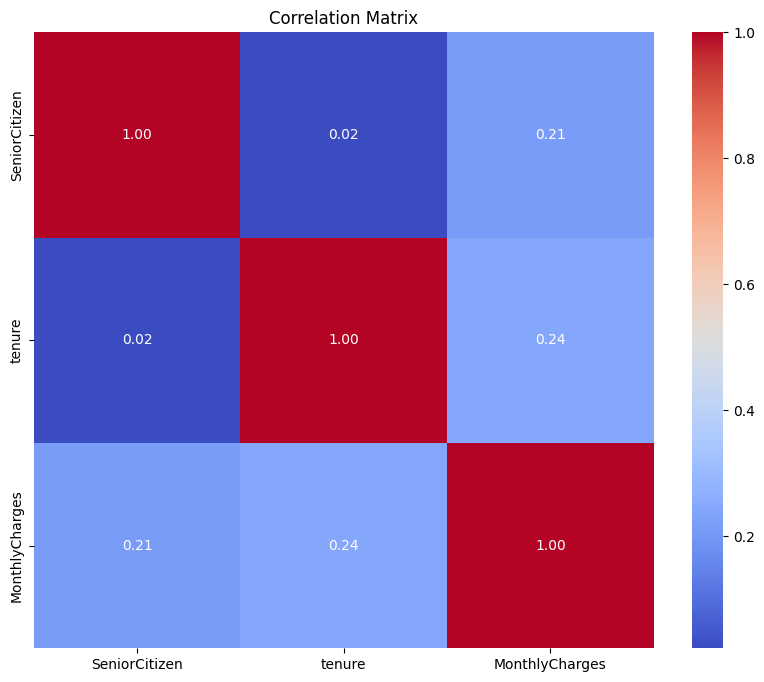

In [22]:
#Heat map with the corelation matrix
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

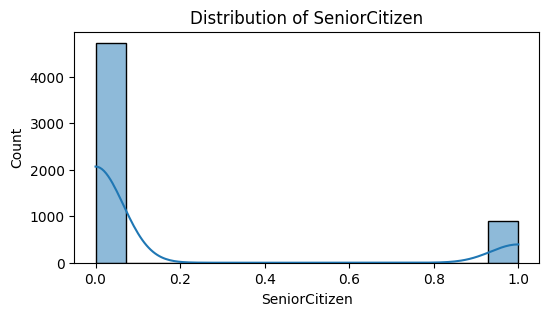

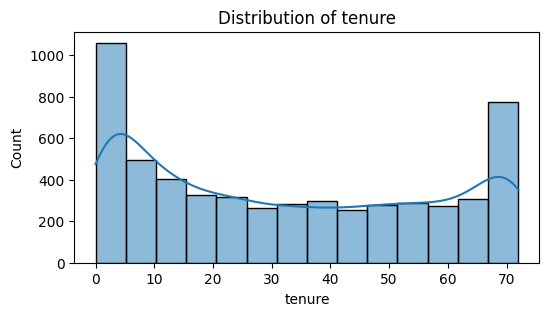

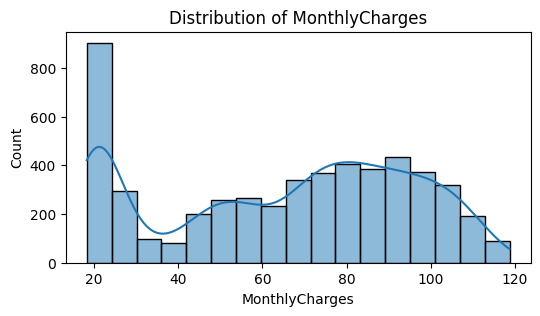

In [23]:
#distribution plot of numeric columns
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(df_training_data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

#####Testing dataset

In [24]:
numeric_cols = df_testing_data.select_dtypes(include=['number']) # Select only numerical columns
numeric_cols.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')

In [25]:
#finding outliers
outlier_counts = {} #empty dict for storing outliers if any

for col in numeric_cols.columns:
    Q1 = df_testing_data[col].quantile(0.25)
    Q3 = df_testing_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df_testing_data[col] < lower) | (df_testing_data[col] > upper)).sum() #sum of the outliers present
    outlier_counts[col] = count

print(outlier_counts['SeniorCitizen'])
print(outlier_counts['tenure'])
print(outlier_counts['MonthlyCharges'])

242
0
0


In [26]:
# correlation
#correlation matrix(numerical columns only because data is not preprocessed)
corr_matrix = numeric_cols.corr()
corr_matrix

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,-0.006990,0.248515
tenure,-0.006990,1.000000,0.277382
MonthlyCharges,0.248515,0.277382,1.000000


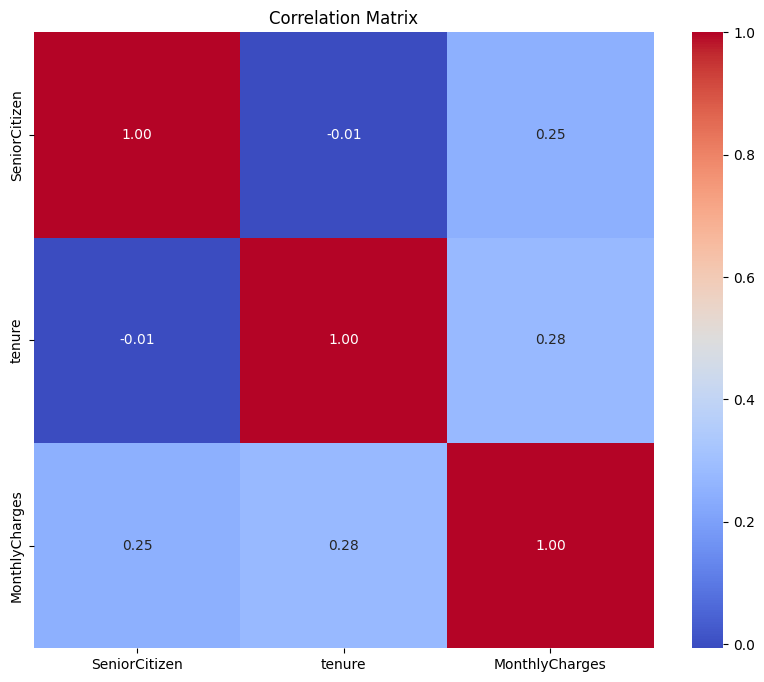

In [27]:
#Heat map with the corelation matrix
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

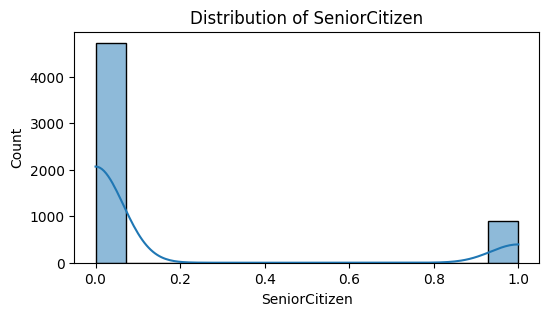

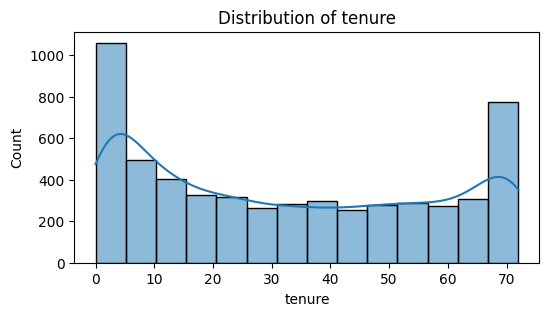

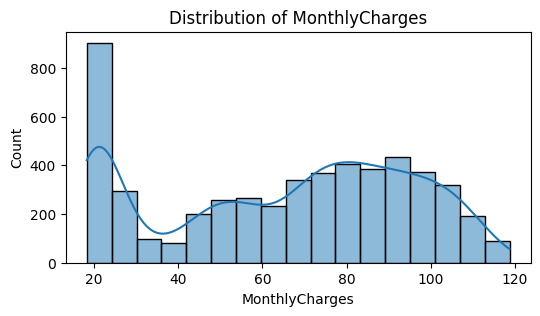

In [28]:
#distribution plot of numeric columns
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(df_training_data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

####Preprocessing

In [29]:
df_training_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5626 entries, 0 to 5633
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5457 non-null   object 
 1   SeniorCitizen     5626 non-null   int64  
 2   Partner           5626 non-null   object 
 3   Dependents        5626 non-null   object 
 4   tenure            5626 non-null   int64  
 5   PhoneService      5626 non-null   object 
 6   MultipleLines     5626 non-null   object 
 7   InternetService   5626 non-null   object 
 8   OnlineSecurity    5457 non-null   object 
 9   OnlineBackup      5626 non-null   object 
 10  DeviceProtection  5626 non-null   object 
 11  TechSupport       5626 non-null   object 
 12  StreamingTV       5626 non-null   object 
 13  StreamingMovies   5626 non-null   object 
 14  Contract          5626 non-null   object 
 15  PaperlessBilling  5626 non-null   object 
 16  PaymentMethod     5626 non-null   object 
 17  

In [30]:
# count of missing values in each column of training dataset
df_training_data.isna().sum()

,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169
OnlineBackup,0


In [31]:
# Filling missing values in Gender using mode
df_training_data['gender'] = df_training_data['gender'].fillna(df_training_data['gender'].mode()[0])

In [32]:
# Filling missing values in OnlineSecurity using mode
df_training_data['OnlineSecurity'] = df_training_data['OnlineSecurity'].fillna(df_training_data['OnlineSecurity'].mode()[0])

In [33]:
# Skew Score
df_training_data['MonthlyCharges'].skew()  # Less than 0 means negative skew

np.float64(-0.23817683929473327)

In [34]:
mean_val = df_training_data['MonthlyCharges'].mean()
median_val = df_training_data['MonthlyCharges'].median()
print(mean_val)
print(median_val)      # Mean < Median = Negative skew(left skewed)

65.15168195718654
70.7


In [35]:
# Filling missing values in MonthlyCharges using median as median is less sensitive to outliers
df_training_data['MonthlyCharges'] = df_training_data['MonthlyCharges'].fillna(df_training_data['MonthlyCharges'].median())

In [36]:
# Converting TotalCharges to numeric
df_training_data['TotalCharges'] = pd.to_numeric(df_training_data['TotalCharges'], errors='coerce')

In [37]:
df_training_data['TotalCharges'].skew() # Greater than 0 means positive skew

np.float64(0.9649564285955939)

In [38]:
mean_val = df_training_data['TotalCharges'].mean()
median_val = df_training_data['TotalCharges'].median()
print(mean_val)
print(median_val)      # Mean > Median = Positive skew(right skewed)

2287.3075243628186
1399.8249999999998


In [39]:
# Filling missing values in TotalCharges using median as median is less sensitive to outliers
df_training_data['TotalCharges'] = df_training_data['TotalCharges'].fillna(df_training_data['TotalCharges'].median())

In [40]:
df_training_data.isna().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [41]:
df_testing_data.isna().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [42]:
# Converting TotalCharges of test data to numeric
df_testing_data['TotalCharges'] = pd.to_numeric(df_testing_data['TotalCharges'], errors='coerce')

####Outlier Analysis

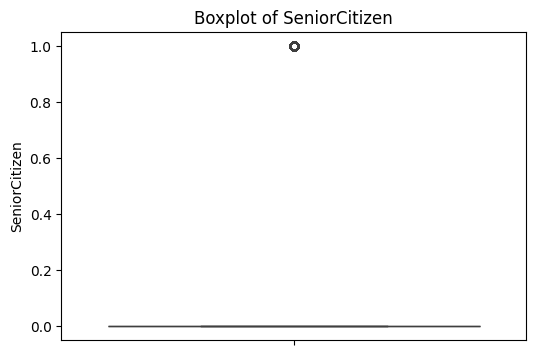

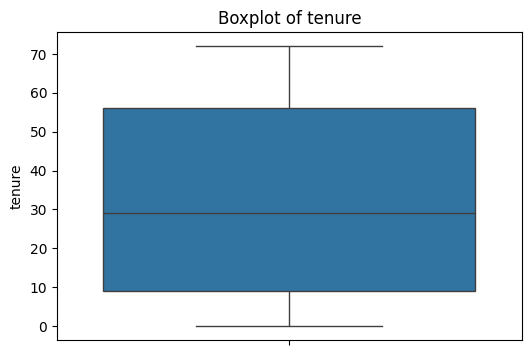

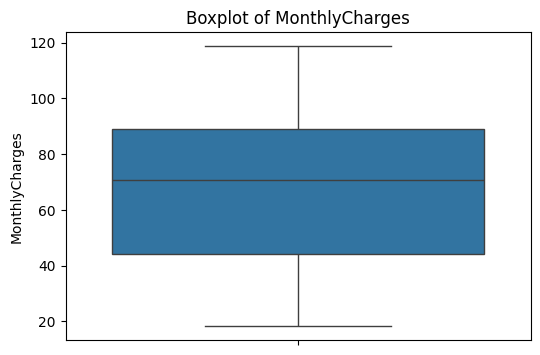

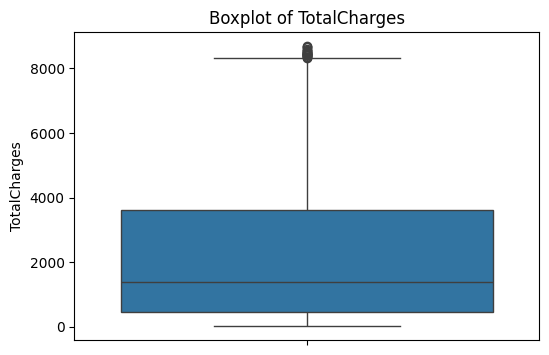

In [43]:
# Training data
numeric_cols = df_training_data.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(df_training_data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

<Axes: ylabel='TotalCharges'>

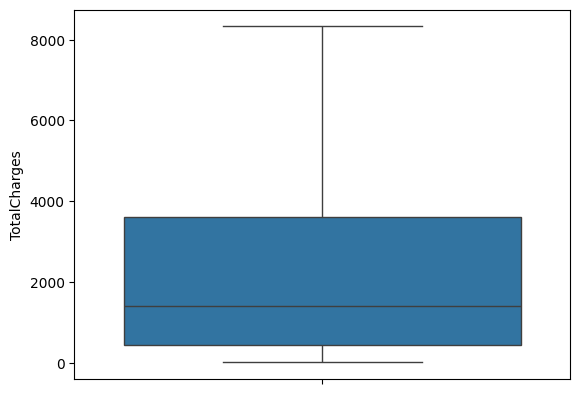

In [44]:
# Clipping outliers of TotalCharges
Q1 = df_training_data['TotalCharges'].quantile(0.25)
Q3 = df_training_data['TotalCharges'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_training_data['TotalCharges'] = df_training_data['TotalCharges'].clip(lower_bound, upper_bound)

sns.boxplot(df_training_data['TotalCharges'])

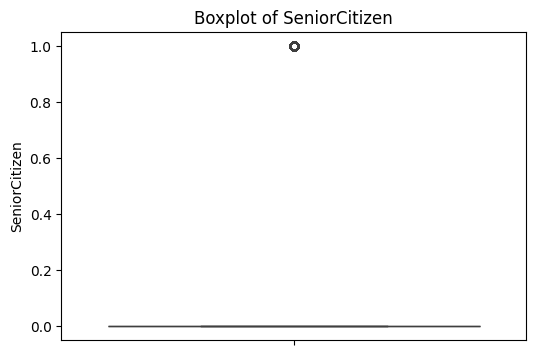

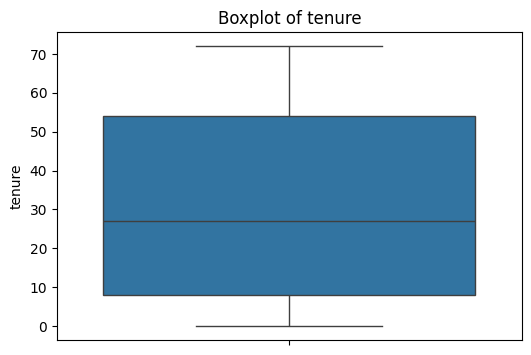

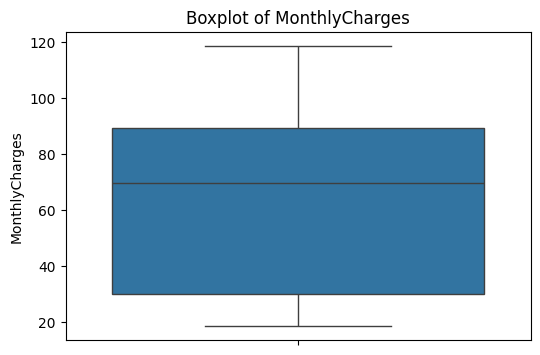

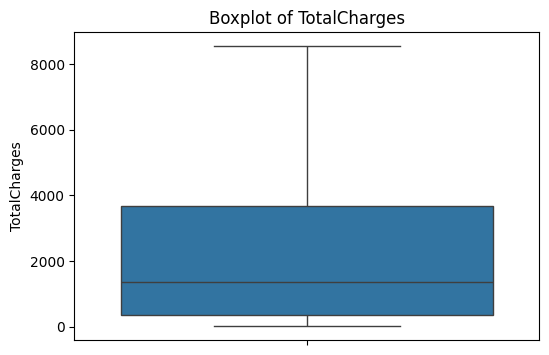

In [45]:
# Test data
numeric_cols = df_testing_data.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(df_testing_data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

####Encoding Categorical Values

#####Training data

In [46]:
df_training_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5626 entries, 0 to 5633
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5626 non-null   object 
 1   SeniorCitizen     5626 non-null   int64  
 2   Partner           5626 non-null   object 
 3   Dependents        5626 non-null   object 
 4   tenure            5626 non-null   int64  
 5   PhoneService      5626 non-null   object 
 6   MultipleLines     5626 non-null   object 
 7   InternetService   5626 non-null   object 
 8   OnlineSecurity    5626 non-null   object 
 9   OnlineBackup      5626 non-null   object 
 10  DeviceProtection  5626 non-null   object 
 11  TechSupport       5626 non-null   object 
 12  StreamingTV       5626 non-null   object 
 13  StreamingMovies   5626 non-null   object 
 14  Contract          5626 non-null   object 
 15  PaperlessBilling  5626 non-null   object 
 16  PaymentMethod     5626 non-null   object 
 17  

In [47]:
# LabelEncoding on Churn column
label_enc = LabelEncoder()
df_training_data['Churn'] = LabelEncoder().fit_transform(df_training_data['Churn'])
df_training_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,No,No,35,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,0
1,Female,0,No,No,28,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,0
2,Male,0,No,No,56,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,0
3,Male,0,Yes,No,39,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,0
4,Female,0,Yes,Yes,43,No,No phone service,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,0


In [48]:
df_training_data['gender'] = df_training_data['gender'].map({'Female': 1, 'Male': 0})
df_training_data['Partner'] = df_training_data['Partner'].map({'Yes': 1, 'No': 0})
df_training_data['Dependents'] = df_training_data['Dependents'].map({'Yes': 1, 'No': 0})
df_training_data['PhoneService'] = df_training_data['PhoneService'].map({'Yes': 1, 'No': 0})
df_training_data['PaperlessBilling'] = df_training_data['PaperlessBilling'].map({'Yes': 1, 'No': 0})

In [49]:
binary_service_cols = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in binary_service_cols:
    df_training_data[col] = df_training_data[col].replace({'No internet service': 'No', 'No phone service': 'No'})
    df_training_data[col] = df_training_data[col].map({'Yes': 1, 'No': 0})

In [50]:
df_training_data['Contract'].unique()

array(['One year', 'Month-to-month', 'Two year'], dtype=object)

In [51]:
df_training_data['Contract'] = df_training_data['Contract'].map({'Month-to-month': 1, 'One year': 12, 'Two year': 24})

In [52]:
df_training_data = pd.get_dummies(df_training_data, columns=['InternetService', 'PaymentMethod'], dtype = int)

In [53]:
df_training_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5626 entries, 0 to 5633
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   5626 non-null   int64  
 1   SeniorCitizen                            5626 non-null   int64  
 2   Partner                                  5626 non-null   int64  
 3   Dependents                               5626 non-null   int64  
 4   tenure                                   5626 non-null   int64  
 5   PhoneService                             5626 non-null   int64  
 6   MultipleLines                            5626 non-null   int64  
 7   OnlineSecurity                           5626 non-null   int64  
 8   OnlineBackup                             5626 non-null   int64  
 9   DeviceProtection                         5626 non-null   int64  
 10  TechSupport                              5626 non-nul

####Feature Engineering

In [54]:
# Create interaction feature
df_training_data['Tenure_Contract'] = df_training_data['tenure'] * df_training_data['Contract']

In [55]:
df_training_data['CLV'] = df_training_data['tenure'] * df_training_data['MonthlyCharges']

####Scaling on training data

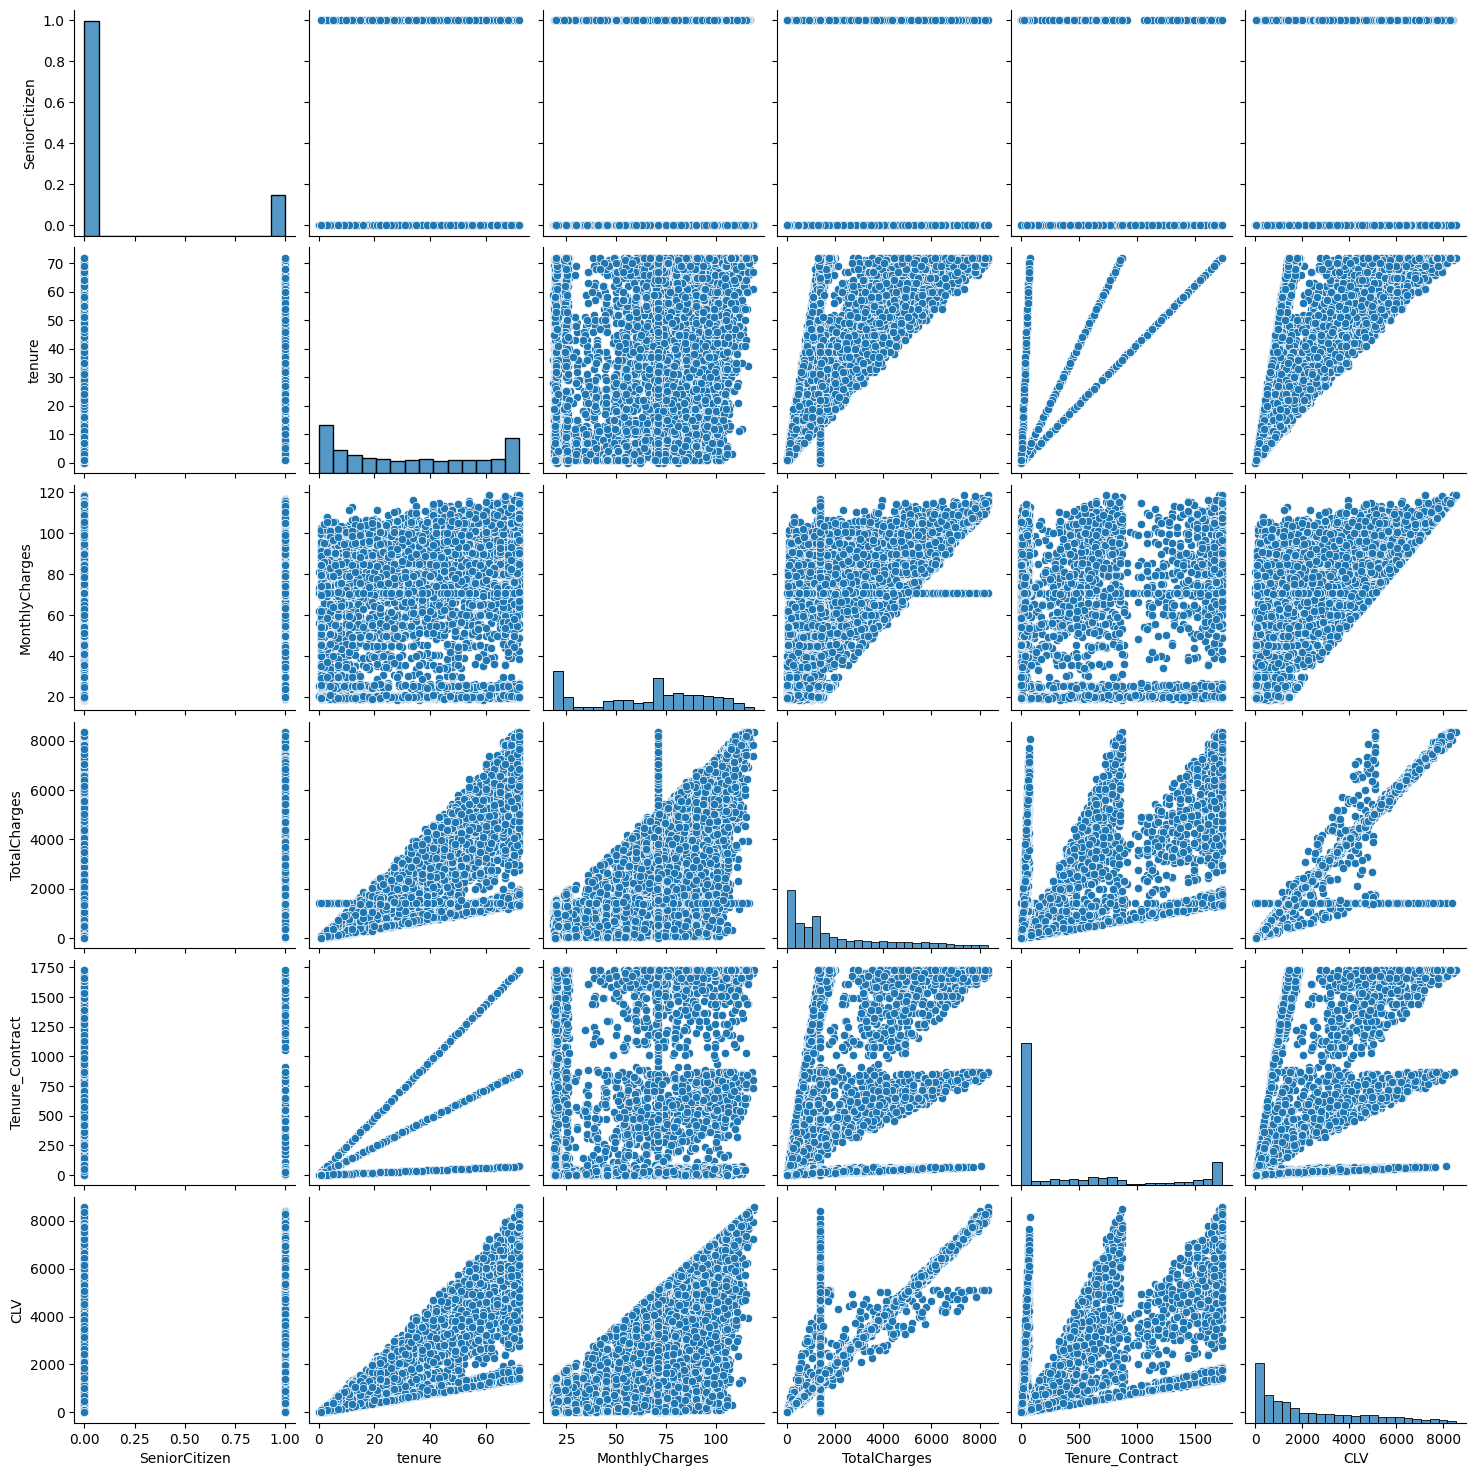

In [56]:
# pairplot to identify type of scaling to be used
sns.pairplot(df_training_data[['SeniorCitizen','tenure','MonthlyCharges','TotalCharges','Tenure_Contract','CLV']])

In [57]:
min_max_scaler = MinMaxScaler(feature_range = (0,1))
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges','Tenure_Contract','CLV']
df_training_data[num_cols]=min_max_scaler.fit_transform(df_training_data[num_cols])
df_training_data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Churn,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Tenure_Contract,CLV
0,1,0,0,0,0.486111,1,0,0,0,0,...,0,0,0,1,0,0,0,1,0.243056,0.084942
1,1,0,0,0,0.388889,0,0,0,0,1,...,0,1,0,0,0,0,0,1,0.016204,0.117076
2,0,0,0,0,0.777778,1,1,0,1,0,...,0,0,1,0,0,0,1,0,0.032407,0.645801
3,0,0,1,0,0.541667,1,0,0,0,0,...,0,0,0,1,1,0,0,0,0.541667,0.093281
4,1,0,1,1,0.597222,0,0,0,1,0,...,0,1,0,0,1,0,0,0,0.298611,0.257749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,0,0,0,0,0.708333,1,0,0,1,1,...,0,0,1,0,0,0,1,0,0.029514,0.590526
5630,0,1,1,0,0.944444,0,0,1,1,1,...,0,1,0,0,0,0,1,0,0.944444,0.333637
5631,0,0,1,1,1.000000,1,0,0,0,0,...,0,0,0,1,1,0,0,0,1.000000,0.168000
5632,1,0,0,0,0.958333,1,0,0,0,1,...,0,1,0,0,0,1,0,0,0.958333,0.665386


#####Test data

In [58]:
df_testing_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1407 entries, 0 to 1408
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            1407 non-null   object 
 1   SeniorCitizen     1407 non-null   int64  
 2   Partner           1407 non-null   object 
 3   Dependents        1407 non-null   object 
 4   tenure            1407 non-null   int64  
 5   PhoneService      1407 non-null   object 
 6   MultipleLines     1407 non-null   object 
 7   InternetService   1407 non-null   object 
 8   OnlineSecurity    1407 non-null   object 
 9   OnlineBackup      1407 non-null   object 
 10  DeviceProtection  1407 non-null   object 
 11  TechSupport       1407 non-null   object 
 12  StreamingTV       1407 non-null   object 
 13  StreamingMovies   1407 non-null   object 
 14  Contract          1407 non-null   object 
 15  PaperlessBilling  1407 non-null   object 
 16  PaymentMethod     1407 non-null   object 
 17  

In [59]:
# LabelEncoding on Churn column
label_enc = LabelEncoder()
df_testing_data['Churn'] = LabelEncoder().fit_transform(df_testing_data['Churn'])
df_testing_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.30,0
1,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,No,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,0
2,Male,0,No,No,43,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,1
3,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,0
4,Female,0,No,No,10,No,No phone service,DSL,No,Yes,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374.00,0


In [60]:
df_testing_data['gender'] = df_testing_data['gender'].map({'Female': 1, 'Male': 0})
df_testing_data['Partner'] = df_testing_data['Partner'].map({'Yes': 1, 'No': 0})
df_testing_data['Dependents'] = df_testing_data['Dependents'].map({'Yes': 1, 'No': 0})
df_testing_data['PhoneService'] = df_testing_data['PhoneService'].map({'Yes': 1, 'No': 0})
df_testing_data['PaperlessBilling'] = df_testing_data['PaperlessBilling'].map({'Yes': 1, 'No': 0})

In [61]:
binary_service_cols = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in binary_service_cols:
    df_testing_data[col] = df_testing_data[col].replace({'No internet service': 'No', 'No phone service': 'No'})
    df_testing_data[col] = df_testing_data[col].map({'Yes': 1, 'No': 0})

In [62]:
df_testing_data['Contract'] = df_testing_data['Contract'].map({'Month-to-month': 1, 'One year': 12, 'Two year': 24})

In [63]:
df_testing_data = pd.get_dummies(df_testing_data, columns=['InternetService', 'PaymentMethod'], dtype = int)

In [64]:
df_testing_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1407 entries, 0 to 1408
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   1407 non-null   int64  
 1   SeniorCitizen                            1407 non-null   int64  
 2   Partner                                  1407 non-null   int64  
 3   Dependents                               1407 non-null   int64  
 4   tenure                                   1407 non-null   int64  
 5   PhoneService                             1407 non-null   int64  
 6   MultipleLines                            1407 non-null   int64  
 7   OnlineSecurity                           1407 non-null   int64  
 8   OnlineBackup                             1407 non-null   int64  
 9   DeviceProtection                         1407 non-null   int64  
 10  TechSupport                              1407 non-nul

In [65]:
# Create interaction feature
df_testing_data['Tenure_Contract'] = df_testing_data['tenure'] * df_testing_data['Contract']

In [66]:
df_testing_data['CLV'] = df_testing_data['tenure'] * df_testing_data['MonthlyCharges']

####Scaling on Test data

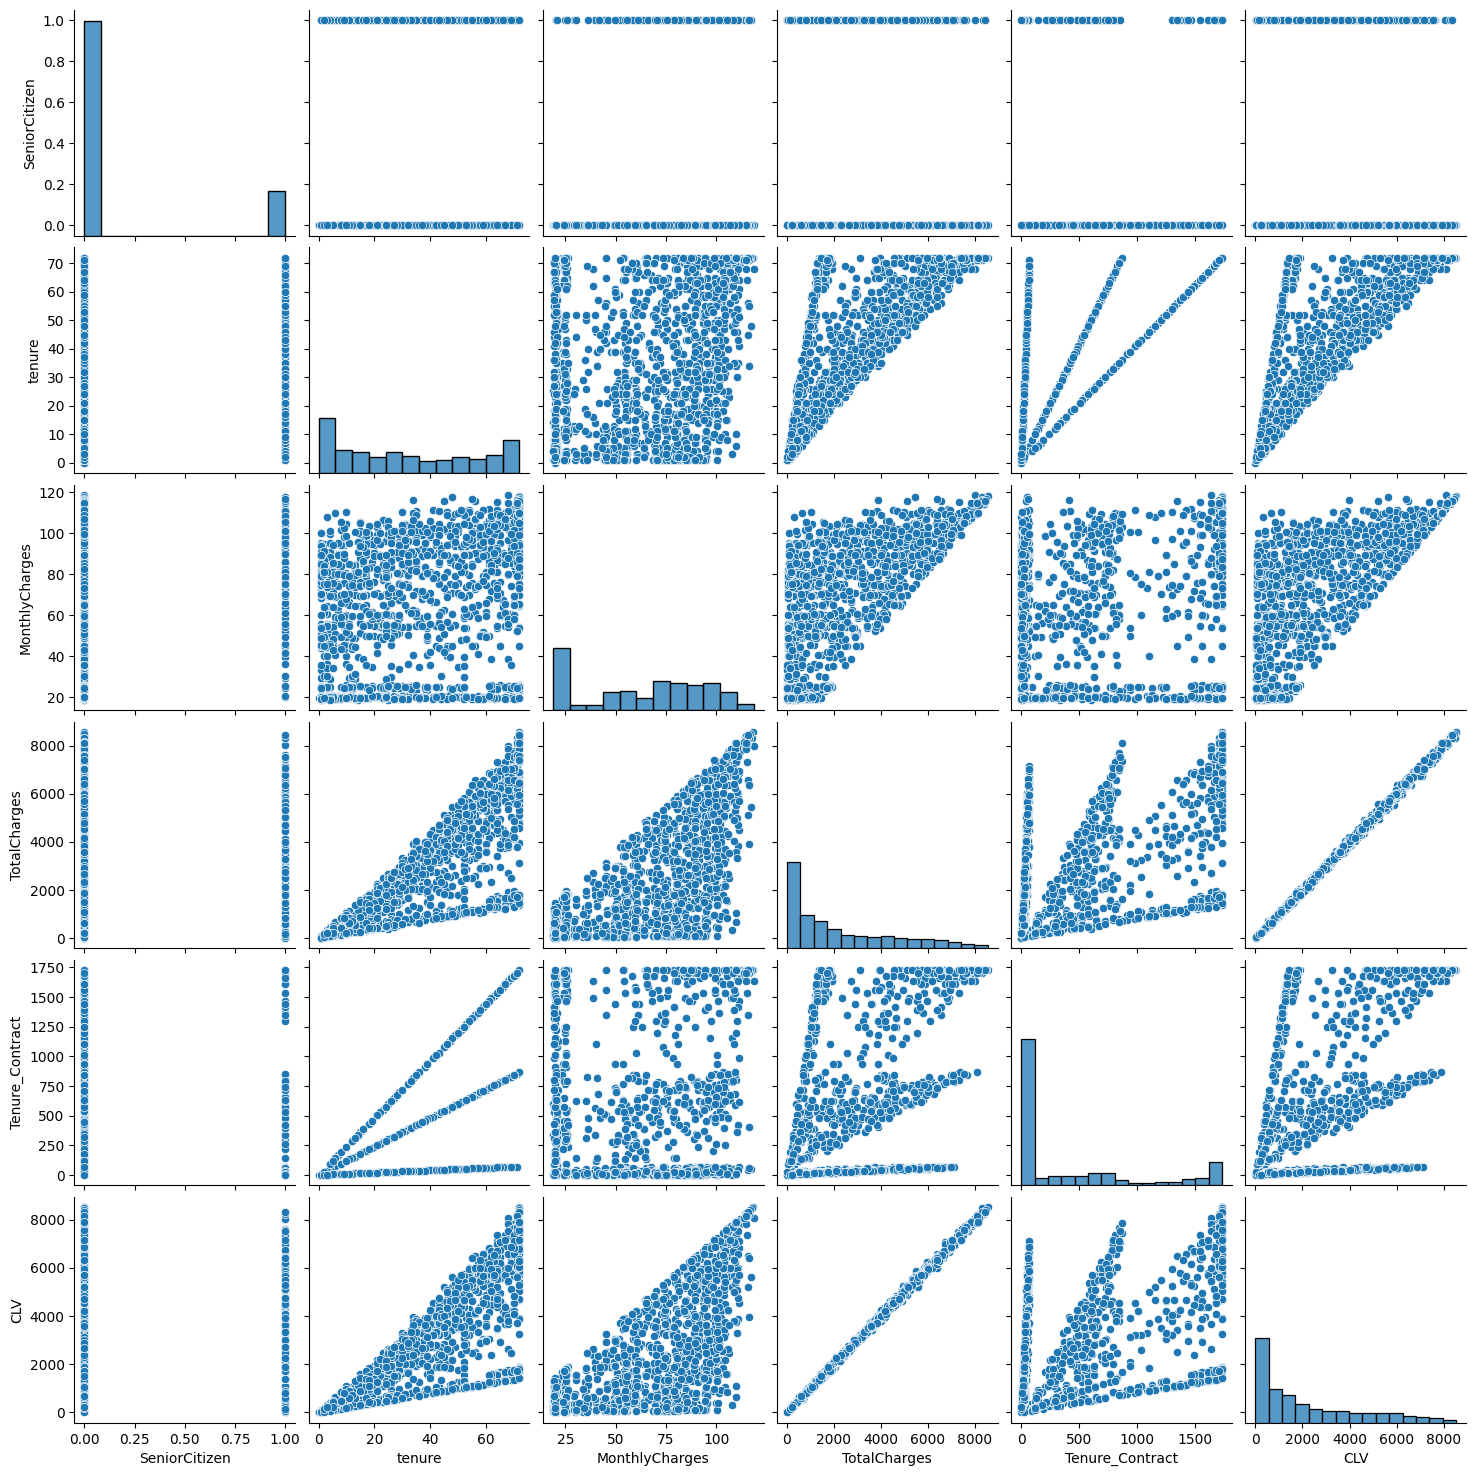

In [67]:
# pairplot to identify type of scaling to be used
sns.pairplot(df_testing_data[['SeniorCitizen','tenure','MonthlyCharges','TotalCharges','Tenure_Contract','CLV']])

In [68]:
min_max_scaler = MinMaxScaler(feature_range = (0,1))
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges','Tenure_Contract','CLV']
df_testing_data[num_cols]=min_max_scaler.fit_transform(df_testing_data[num_cols])
df_testing_data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Churn,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Tenure_Contract,CLV
0,0,0,1,1,0.555556,1,1,0,0,1,...,0,0,1,0,0,0,1,0,0.023148,0.381651
1,1,0,1,0,0.166667,1,1,1,0,1,...,0,1,0,0,0,0,1,0,0.083333,0.111182
2,0,0,0,0,0.597222,1,1,0,0,0,...,1,0,1,0,0,0,1,0,0.298611,0.505264
3,0,0,0,0,1.000000,1,1,1,1,1,...,0,0,1,0,0,0,1,0,1.000000,1.000000
4,1,0,0,0,0.138889,0,0,0,1,0,...,0,1,0,0,0,0,1,0,0.005787,0.042595
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1404,0,0,0,0,0.375000,1,0,1,1,0,...,0,1,0,0,1,0,0,0,0.187500,0.175920
1405,1,1,0,0,0.027778,1,1,0,0,0,...,1,0,1,0,0,0,0,1,0.001157,0.017731
1406,1,0,1,0,0.041667,1,1,0,0,0,...,1,0,1,0,0,1,0,0,0.001736,0.026491
1407,0,0,1,1,0.736111,1,0,0,0,0,...,0,0,0,1,0,1,0,0,0.368056,0.125799


####Model Building

In [71]:
X_train = df_training_data.drop('Churn', axis=1)
y_train = df_training_data['Churn']

X_test = df_testing_data.drop('Churn', axis=1)
y_test = df_testing_data['Churn']

####Model Implementation

In [78]:
# Initialize models
log_model = LogisticRegression(max_iter=1000)
rf_model = RandomForestClassifier()
svm_model = SVC(probability=True)

# Fit models
log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)

SVC(probability=True)

####Model Evaluation

In [84]:
def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    print(f"\n Evaluation for {name}")
    print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")


# Filling missing values in TotalCharges of test data using median
df_testing_data['TotalCharges'] = df_testing_data['TotalCharges'].fillna(df_testing_data['TotalCharges'].median())

# Re-assign X_test after filling NaN values
X_test = df_testing_data.drop('Churn', axis=1)
y_test = df_testing_data['Churn']

# Evaluate each model with the corrected X_test
evaluate_model(log_model, "Logistic Regression")
evaluate_model(rf_model, "Random Forest")
evaluate_model(svm_model, "Support Vector Machine")


 Evaluation for Logistic Regression
Accuracy  : 0.8195
Precision : 0.6833
Recall    : 0.5632
F1 Score  : 0.6175

 Evaluation for Random Forest
Accuracy  : 0.7832
Precision : 0.6028
Recall    : 0.4753
F1 Score  : 0.5315

 Evaluation for Support Vector Machine
Accuracy  : 0.8081
Precision : 0.6577
Recall    : 0.5385
F1 Score  : 0.5921


In [87]:
results = []

for model, name in zip([log_model, rf_model, svm_model],
                       ["Logistic Regression", "Random Forest", "SVM"]):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1 Score', ascending=False, ignore_index=True)

####Logistics Regression is better in accuracy than SVM and random forest.

In [88]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.819474,0.683333,0.563187,0.617470
1,SVM,0.808102,0.657718,0.538462,0.592145
2,Random Forest,0.783227,0.602787,0.475275,0.531490


####Model Fine-Tuning

#####RandomizedSearchCV

In [89]:
# Define parameter grid
param_dist = {
    'n_estimators': np.arange(100, 501, 50),
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]}

In [90]:
# Initialize model
rf = RandomForestClassifier(random_state=42)

In [94]:
# Randomized Search CV
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,               # number of combinations to try
    cv=5,                    # 5-fold cross validation
    scoring='roc_auc',       # optimize for ROC-AUC
    random_state=42,
    n_jobs=-1,               # use all CPU cores
    verbose=2
)

# Fit on training data
rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 5, 10, 15, 20],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4, 6],
                                        'min_samples_split': [2, 5, 10, 15],
                                        'n_estimators': array([100, 150, 200, 250, 300, 350, 400, 450, 500])},
                   random_state=42, scoring='roc_auc', verbose=2)

In [97]:
from sklearn.metrics import classification_report, roc_auc_score

# Best parameters
print("\nBest Parameters:", rf_random.best_params_)

# Evaluate tuned model
best_rf = rf_random.best_estimator_
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

print("\nClassification Report (Tuned RF):")
print(classification_report(y_test, y_pred))
print("ROC-AUC (Tuned RF):", roc_auc_score(y_test, y_proba))


Best Parameters: {'n_estimators': np.int64(200), 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 5, 'bootstrap': True}

Classification Report (Tuned RF):
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1043
           1       0.65      0.46      0.54       364

    accuracy                           0.80      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.80      0.78      1407

ROC-AUC (Tuned RF): 0.8289657370433977


Random Forest was chosen because it performed best in the baseline comparison.

Parameters were tuned to balance bias-variance trade-off and prevent overfitting while improving generalization.
